# Module 7 - Consolidated Evaluation

All seven methods scored on the **same** held-out split (per-user leave-out, seed 42), with accuracy, beyond-accuracy, popularity-bias, and scalability metrics. (The report's headline table averages these over five seeds; the figures below use one seed for clarity.) Figures are saved to `docs/figures/` for the slide deck.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from recsys.config import (RAW_DIR, USER_ARTISTS_FILE, USER_TAGGED_ARTISTS_FILE,
    USER_FRIENDS_FILE, ARTISTS_FILE, DEFAULT_SEED, PROCESSED_DIR)
from recsys.data.loader import (load_user_artists, load_user_tagged_artists,
    load_user_friends, load_artists)
from recsys.data.split import leave_n_out_split
from recsys.eval.beyond_accuracy import BeyondAccuracyInputs, build_item_popularity
from recsys.eval.harness import compare_models
from recsys.models.popularity import PopularityRecommender
from recsys.models.cf import ItemKNNRecommender, UserKNNRecommender
from recsys.models.content import ContentBasedRecommender, build_artist_tag_profiles
from recsys.models.mf import ImplicitALS
from recsys.models.social import SocialRecommender

sns.set_theme(style='whitegrid')
FIG_DIR = PROCESSED_DIR.parents[1] / 'docs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
interactions = load_user_artists(RAW_DIR / USER_ARTISTS_FILE)
tagged = load_user_tagged_artists(RAW_DIR / USER_TAGGED_ARTISTS_FILE)
friends = load_user_friends(RAW_DIR / USER_FRIENDS_FILE)
n_catalogue = len(load_artists(RAW_DIR / ARTISTS_FILE))
train, test = leave_n_out_split(interactions, seed=DEFAULT_SEED)
profiles, artist_ids = build_artist_tag_profiles(tagged)
beyond = BeyondAccuracyInputs(profiles=profiles,
    item_to_row={int(a): i for i, a in enumerate(artist_ids)},
    popularity=build_item_popularity(train), n_catalogue=n_catalogue)

models = {
    'Item-item CF': ItemKNNRecommender(),
    'ALS (MF)': ImplicitALS(),
    'User-user CF': UserKNNRecommender(),
    'Social (friends)': SocialRecommender(friends),
    'Content-based': ContentBasedRecommender(tagged),
    'Pop (listeners)': PopularityRecommender('listeners'),
    'Pop (plays)': PopularityRecommender('plays'),
    'Pop (damped)': PopularityRecommender('damped'),
}
table = compare_models(models, train, test, k=10, beyond=beyond)
table.round(4)

,precision_at_k,recall_at_k,map_at_k,ndcg_at_k,k,n_users,fit_seconds,recommend_ms,coverage,diversity,novelty,popularity_bias,exposure_gini
Item-item CF,0.1749,0.1775,0.1135,0.2174,10.0,1884.0,0.0192,0.2532,0.1556,0.6161,4.7487,0.0843,0.9688
ALS (MF),0.1344,0.1375,0.0667,0.1502,10.0,1884.0,6.2936,0.2199,0.1028,0.7451,4.9145,0.0533,0.9673
User-user CF,0.1292,0.1329,0.0805,0.1598,10.0,1884.0,0.0252,0.2614,0.0180,0.6193,2.9797,0.1405,0.9974
Social (friends),0.1235,0.1266,0.0781,0.1533,10.0,1884.0,0.0066,0.1263,0.1421,0.7102,4.8338,0.0760,0.9651
Content-based,0.0994,0.1011,0.0498,0.1144,10.0,1884.0,0.0392,0.4734,0.1434,0.3382,6.5683,0.0337,0.9613
Pop (listeners),0.0691,0.0703,0.0351,0.0798,10.0,1884.0,0.0121,0.1717,0.0015,0.6271,2.4420,0.1864,0.9993
Pop (plays),0.0602,0.0615,0.0267,0.0653,10.0,1884.0,0.0111,0.1774,0.0014,0.6759,2.6821,0.1645,0.9993
Pop (damped),0.0430,0.0437,0.0153,0.0441,10.0,1884.0,0.0127,0.1762,0.0012,0.7652,3.4366,0.1195,0.9994


## 1. Accuracy: personalisation more than doubles the baseline

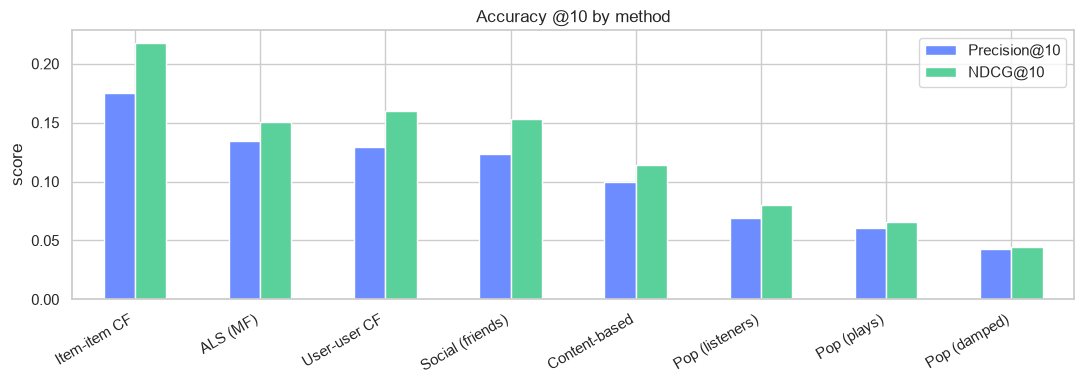

In [3]:
acc = table[['precision_at_k','ndcg_at_k']]
ax = acc.plot(kind='bar', figsize=(11,4), color=['#6c8cff','#5ad19a'])
ax.set_ylabel('score'); ax.set_title('Accuracy @10 by method')
ax.set_xticklabels(acc.index, rotation=30, ha='right')
ax.legend(['Precision@10','NDCG@10'])
plt.tight_layout(); plt.savefig(FIG_DIR/'eval_accuracy.png', dpi=120); plt.show()

## 2. Beyond-accuracy: coverage, diversity, novelty

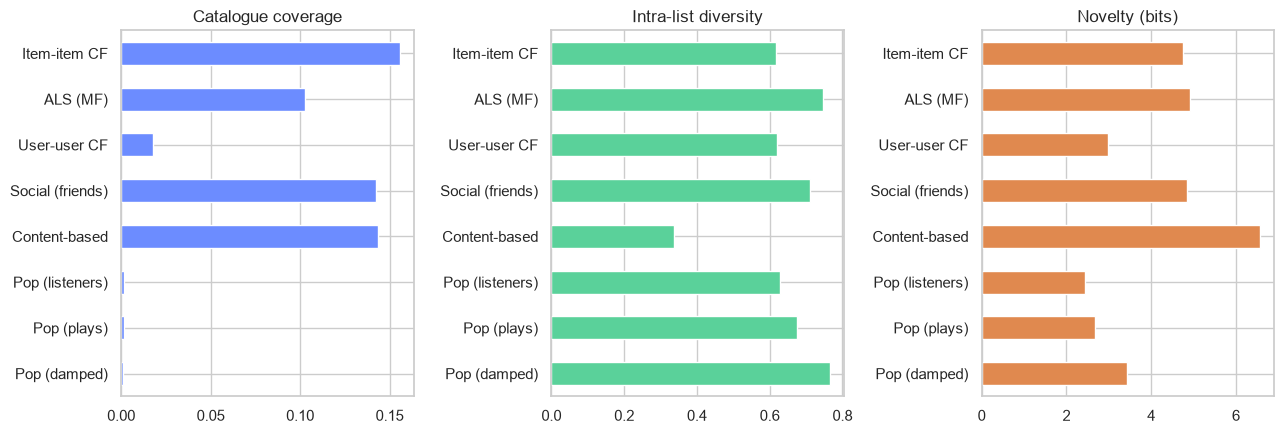

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13,4.5))
for ax, col, title, color in zip(axes,
        ['coverage','diversity','novelty'],
        ['Catalogue coverage','Intra-list diversity','Novelty (bits)'],
        ['#6c8cff','#5ad19a','#e0894f']):
    table[col].plot(kind='barh', ax=ax, color=color)
    ax.set_title(title); ax.invert_yaxis()
plt.tight_layout(); plt.savefig(FIG_DIR/'eval_beyond_accuracy.png', dpi=120); plt.show()

## 3. The core trade-off: accuracy vs diversity

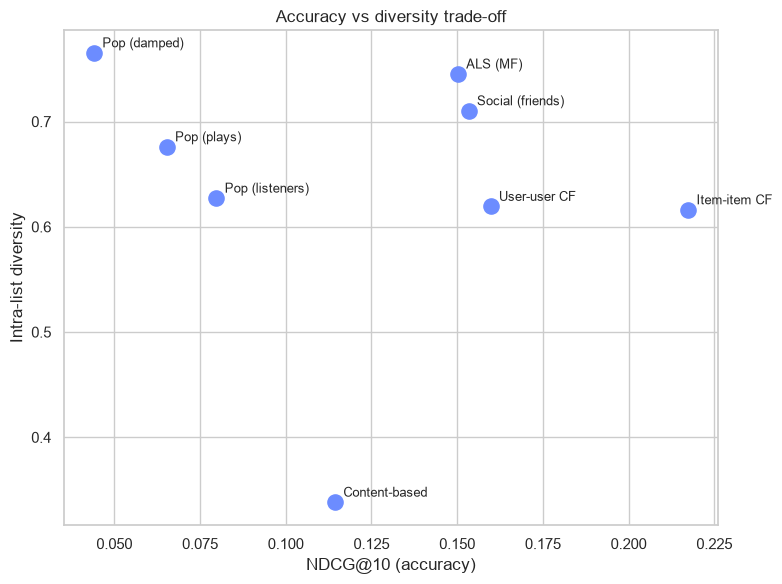

In [5]:
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(table['ndcg_at_k'], table['diversity'], s=120, c='#6c8cff')
for name, row in table.iterrows():
    ax.annotate(name, (row['ndcg_at_k'], row['diversity']),
        xytext=(6,4), textcoords='offset points', fontsize=9)
ax.set_xlabel('NDCG@10 (accuracy)'); ax.set_ylabel('Intra-list diversity')
ax.set_title('Accuracy vs diversity trade-off')
plt.tight_layout(); plt.savefig(FIG_DIR/'eval_tradeoff.png', dpi=120); plt.show()

## 4. Popularity bias and scalability

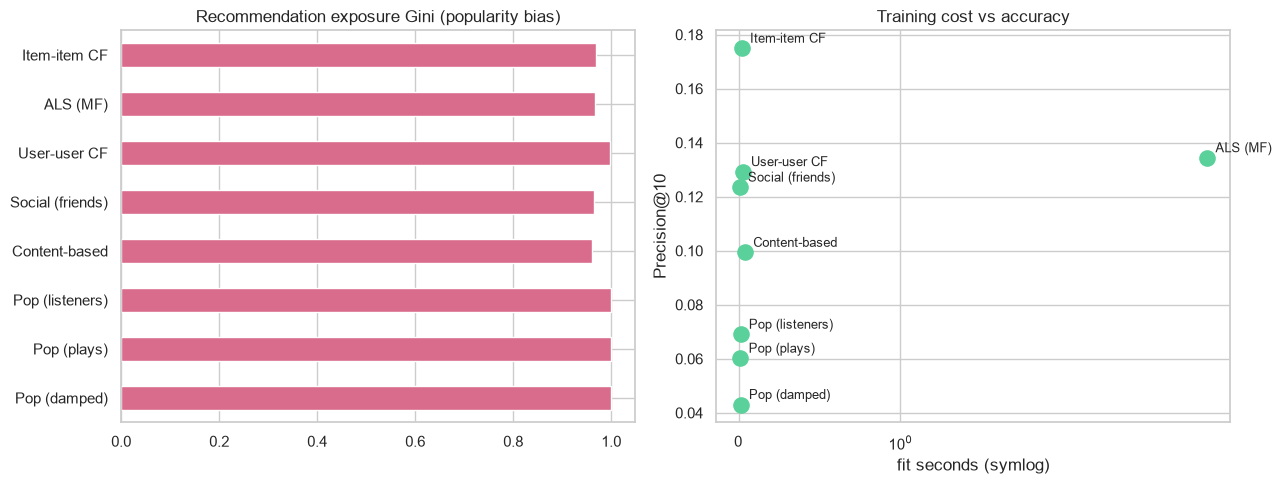

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
table['exposure_gini'].plot(kind='barh', ax=axes[0], color='#d96c8c')
axes[0].set_title('Recommendation exposure Gini (popularity bias)'); axes[0].invert_yaxis()
axes[1].scatter(table['fit_seconds'], table['precision_at_k'], s=120, c='#5ad19a')
for name, row in table.iterrows():
    axes[1].annotate(name, (row['fit_seconds'], row['precision_at_k']),
        xytext=(6,4), textcoords='offset points', fontsize=9)
axes[1].set_xscale('symlog'); axes[1].set_xlabel('fit seconds (symlog)')
axes[1].set_ylabel('Precision@10'); axes[1].set_title('Training cost vs accuracy')
plt.tight_layout(); plt.savefig(FIG_DIR/'eval_scalability_bias.png', dpi=120); plt.show()

## Takeaways

- **Personalisation wins on accuracy:** item-item CF ~2.5x the best popularity baseline.
- **No single best method:** item-CF leads accuracy + coverage; ALS gives the most
  diverse accurate lists; content-based is the most novel but least diverse; the social
  recommender nearly matches user-user CF with much broader coverage.
- **Popularity bias is real and measurable:** popularity methods have tiny coverage and
  the highest exposure Gini - the same handful of artists shown to everyone.
- **Scalability differs by family:** memory-based CF trains instantly but stores a big
  similarity matrix; ALS pays an upfront training cost for compact, fast serving.